# Introduction

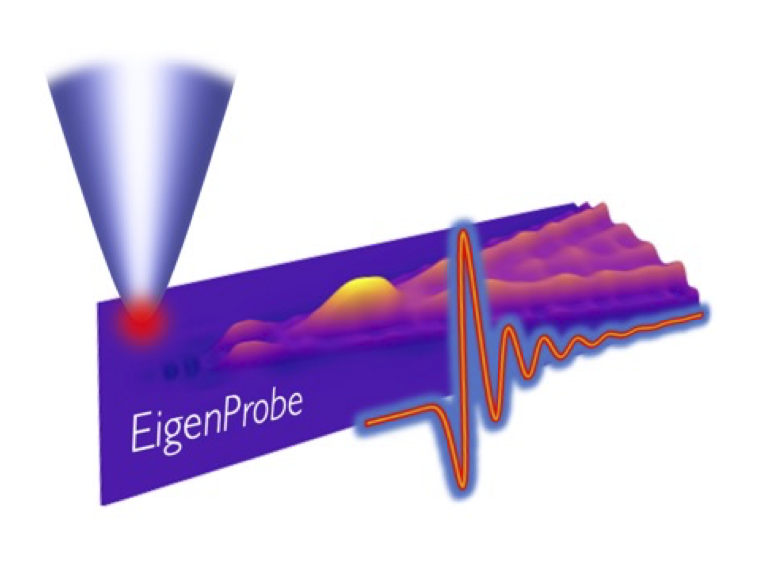

In [7]:
from IPython.display import Image
Image("../Documentation/EigenProbe_Logo.png",width=500)

Here we will achieve the following goals.  Each of these calculations produces an object that is a necessary ingredient for the subsequent calculation.  Each resulting object can be optionally loaded from file, recomputed, and saved.
* Build a probe around a standard conical geometry using a `Probe` object, compute its eigenmodes, and inspect its eigenvalues.
* Determine how eigenvalues disperse with probe-sample distance using a `ProbeGapSpectroscopy` object.  (We multi-thread this calculation using a `Parallel` version.)
* Build a compact description of the probe, its eigenfields, and their gap-dependence using a `EncodedEigenfields` object.
* Determine how eigenvalues disperse with excitation energy using a `ProbeFrequencySpectroscopy` object.  (We multi-thread this calculation using a `Parallel` version.)

# Imports

## General Imports

In [1]:
import os,time,sys,pickle
from matplotlib import pyplot as plt
from importlib import reload
import numpy as np

/usr/local/Cellar/micromamba/2.8.1/envs/EigenProbe/lib/python3.9/site-packages/llvmlite/binding/ffi.py:175: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Numba 0.54.1 is known to work well with this package.
Numba version that was imported: 0.54.1
Numpy 1.20.3 is known to work well with this package.
Numpy version that was imported: 1.20.3


## Specialized Imports

In [2]:
from common.baseclasses import AWA # https://github.com/asmcleod/common.git
from common.misc import flatten
from common import numerical_recipes as numrec

# It is known that `sympy` wraps `numpy` universal functions in a way that conflicts with `numba`.  Avoid importing `Materials` until necessary.
#from NearFieldOptics import Materials as M # https://github.com/asmcleod/NearFieldOptics.git
#from NearFieldOptics.Materials import material_types,TransferMatrixMedia

## EigenProbe tools

In [3]:
import EigenProbe as EP # https://github.com/asmcleod/EigenProbe.git
from EigenProbe import RotationalMoM as RotMOM
from EigenProbe import ProbeSpectroscopy as PS
from EigenProbe import EigenInversion as EI

sys.modules['ProbeCavityEigenfields'] = EP # This hook allows to continue to load probe files that were previously saved under an older alias for `EigenProbe`

<plotting>:
	Registered colormaps "Warm" and "Warm_r"...
<plotting>:
	Registered colormaps "vanheum" and "vanheum_r"...
<plotting>:
	Registered colormaps "NT-MDT" and "NT-MDT_r"...
<plotting>:
<plotting>:
	Registered colormaps "jingdi" and "jingdi_r"...
<plotting>:
	Registered colormaps "Halcyon" and "Halcyon_r"...
<plotting>:
	Registered colormaps "Cold" and "Cold_r"...
<plotting>:
	Registered colormaps "Sky" and "Sky_r"...
<plotting>:
	Registered colormaps "Gwyddion.net" and "Gwyddion.net_r"...
<plotting>:
	Registered colormaps "BlueRed" and "BlueRed_r"...
<plotting>:
	Registered colormaps "vanheum3" and "vanheum3_r"...
<plotting>:
	Registered colormaps "vanheum2" and "vanheum2_r"...


# Build probe

A probe (class `EP.Probe`) is constructed by specifying its overall geometry.  Shape `geometry` can be quick-configued with keywords sphere, ellipsoid, hyperboloid, cone, etc.  The length of any of these is quantified with `L`, their sharpness (tip radius) by `a`, and the outer angle (with respect to vertical) of the latter two geometries is specified by `taper_angle`.  

The probe axi-symmetric geometry is established over a grid of $z$ values that are finely sampled at top and bottom of the probe (e.g. Gauss-Legendre or Tanh-Sinh quadrature) in order to better resolve the sharp asperities that appear there for most geometries.  There will be `Nnodes` of these, and will be coerced to the nearest convenient number for quadrature.  At each $z-$node resides a "pulse" basis element (e.g. sawtooth) whose distribution of current is internally sampled over `Nsubmodes` (usually 2 is sufficient).  The non-uniform grid of $z$-nodes also best resolves quasi-electrostatic interactions that decay exponentially with distance from the "bottom" of the probe, since the planar "sample" is placed a probe-sample gap distance $d$ below the bottom asperity of the probe.

Electrodynamic properties are controlled by the frequency `freq` at which the probe interacts with its environment, particularly through retardance of the (to-be-computed) self-impedance matrix.  To simplify internal implmeentations, the speed of light is set to 1 throughout the interface, such that all units are "length-full", and consequently frequency $\omega$ and corresponding free-space light wavelength $\lambda$ are related by $\omega=1/\lambda$.

The class-wide data type (e.g. for electromagnetic four-potential, eigencharges, etc.) is established with `EP.Probe.dtype`, and `np.complex64` supplies a good balance of dynamic range and expediency for expensive quadrature calculations.

Probe geometry can be inspected with $z$-values and corresponding axisymmetric radii $R$ obtained from `Probe.get_zs` and `Probe.get_radii`.

In [4]:
a_nm=20 # probe radius in nanometers
a=a_nm*1e-7 #in cm
L=24e-4 #probe length in cm, assuming added cantilever thickness 4e-4 #Arrow probe: https://www.nanoworld.com/tapping-mode-reflex-coated-afm-tip-arrow-ncr
L_microns=L*1e4
taper_angle=21 # Arrow probe: https://www.researchgate.net/figure/SEM-image-of-an-AFM-tip-attached-to-cantilever_fig6_224406883
geometry='hyperboloid'

WL_THz=300e-4 #300 microns wavelength
freq_THz=1/WL_THz
freq=30*freq_THz # 30 THz

Nsubnodes=2 # 2 or 4 are common values; can be any integer number, but greater than four gains questionably more accuracy and adds great expense.  Experience shows 2 is usually sufficient.
Nnodes=244 # 244 is a good balance of cost and accuracy.  The number will be coerced to the nearest available quadrature grid length.
EP.Probe.dtype = np.complex64

probe_name = '%s_a=%inm_taper=%i_L=%imicrons_Nnodes=%i'%(geometry.capitalize(),a_nm,taper_angle,L_microns,Nnodes)
#probe_name = 'MidIRHyperboloid_FreqDepNormalization_L=%imicrons'%(L*1e4,)
print('Building probe %s...'%probe_name)

Building probe Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=488...


The probe is ready to compute interactions with a sample only once its gap distance `d` is set, and once is self-($\omega$-specific) and mirror-($d$-specific) impedance matrices are computed.  The former is computed (`Probe.get_self_impedance`) by adaptive quadrature as a superposition of "Green functions" from each axisymmetric "pulse" basis element along the exterior of the probe's length. (The probe is assumed a perfect conductor, with no internal degrees of freedom.)  The latter is by default also computed (`Probe.get_mirror_impedance`) by adaptive quadrature, or instead with sommerfeld integrals (keyword `sommerfeld=True`); the latter demands a quadrature grid of $\kappa$ values specifiable by `Nkappas` that alternatively defaults to a (naive) best-guess Tanh-Sinh quadrature grid.  The Sommerfeld calculation is faster but convergence must be carefully checked and is not guaranteed for arbitrary geometries.  By contrast, adaptive quadrature calculations should be accurate to machine precision (up to maximum evaluations set by `RotMOM.quadlimit`); fundamental inaccuracies owe to the finite number of "nodes" along the probe. 

Once these impedance matrices are computed, eigenmodes (values $\rho_\nu$ and corresponding vectors $Q_\nu$) are obtained as solutions to the generalized eigenvalue problem described by self- and mirror-impedances.  To obtain the eigenmodes, use `Probe.solve_eigenmodes` with optional conditioning (coercion to positive-definiteness) of the impedance matrices.  The eigenvalues $rho_\nu$ are visualized by `Probe.plot_eigenrhos`; physically meaningful (spatially confined and radiative) eigenmodes have positive real and negative imaginary parts of $\rho_nu$.

Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=488)_Probe.pickle"...
Could not add probe to `ProbesCollection.` 
A probe named "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=488" is already instantiated!  If you wish to overwrite this probe, remove it from the collection of probes by using the `del` command!
You may avert this error by passing keyword `overwrite=True` to `load`!
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=488)_Probe.pickle"!


Text(0, 0.5, 'z (cm)')

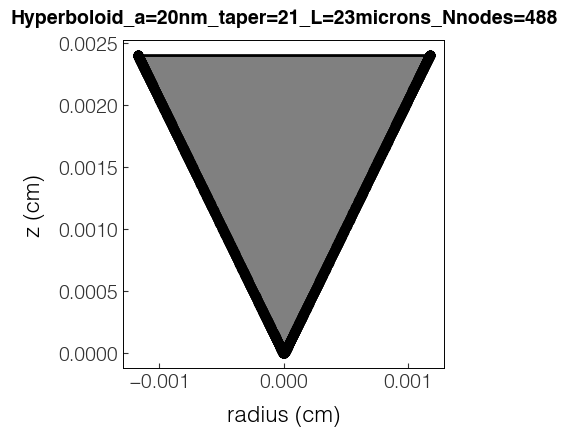

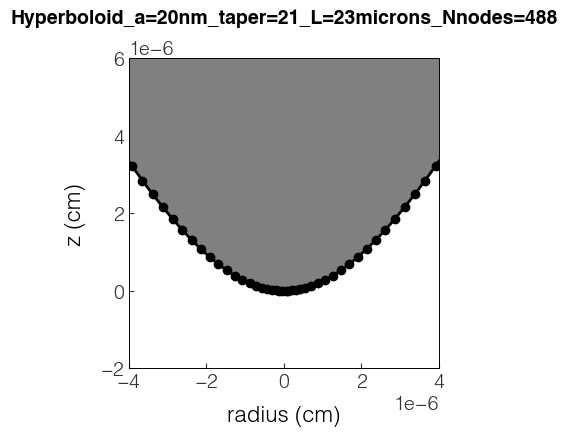

In [40]:
# Load the probe or build the probe
recompute = False
overwrite = False
try:
    if recompute: raise ValueError
    P = EP.load(probe_name,EP.Probe)
except (FileNotFoundError,ValueError): 

    P=EP.Probe(Nnodes=Nnodes,Nsubnodes=Nsubnodes,L=L,quadrature=numrec.TS,\
                     a=a,taper_angle=taper_angle,geometry=geometry,
                freq=freq,gap=a,name=probe_name)

    RotMOM.quadlimit = int(1e4) # maximum evaluations of interaction kernel per node of probe
    #Zmirror = P.get_mirror_impedance(k=0,kappa_min=.1/L,recompute=False,sommerfeld=True,Nkappas=244*8)
    Zmirror = P.get_mirror_impedance(sommerfeld=False)
    #Zself = P.get_self_impedance(k=P.get_k(),recompute=True)
    rhos,Js = P.solve_eigenmodes(condition_ZM=True,condition_ZS=False,ZMthresh=0,recompute_impedance=False)
    
    try: EP.save(P,overwrite=overwrite)
    except OSError: pass
    
ztip=P.get_gap()
zs=P.get_zs()
Rs=P.get_radii()
k=P.get_k()

P.plot_geometry()
plt.gca().set_aspect('equal')
plt.xlabel('radius (cm)')
plt.ylabel('z (cm)')

P.plot_geometry()
plt.xlim(-2*a,2*a)
plt.ylim(-a,3*a)
plt.xlabel('radius (cm)')
plt.ylabel('z (cm)')

#Zmirror = P.get_mirror_impedance(k=P.get_k(),nonsingular=False,recompute=True)
#Zmirror = P.get_mirror_impedance(k=0,nonsingular=False,recompute=True)
#Zmirror = P.get_mirror_impedance(k=P.get_k(),farfield=False,recompute=True,sommerfeld=True,Nkappas=244*8,rp=rp_au,\
#                                kappa_min=P.get_k()*.01)

(0.0, 15.0)

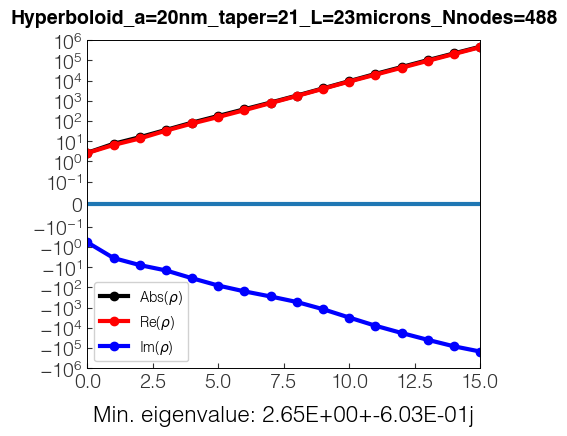

In [6]:
P.plot_eigenrhos()
plt.xlim(0,15)

# Probe Gap Spectroscopy

[TODO]

In [26]:
gaps = np.logspace(-1.5, 1.5, 100) * P.get_a() # in cgs units, like everything else here
#gaps = np.linspace(.1,10,100)*a

recompute=True
save=True
overwrite=False

#kwargs=dict(sommerfeld=True, kappa_max = None, Nkappas = 244*4 ) # adaptive kappa_max
kwargs=dict(sommerfeld=False,basis_gap = P.get_a()) # basis is important

try:
    if recompute: raise ValueError
    ProbeGapSpectroscopy = EP.load(P, PS.ProbeGapSpectroscopyParallel, overwrite_probe=True)
    
except (FileNotFoundError,ValueError):
    ProbeGapSpectroscopy = PS.ProbeGapSpectroscopyParallel(Probe=P, gaps=gaps,
                                                        ncpus=8, backend='loky',
                                                        Nmodes=50, reversed=False,**kwargs)
    if save:
        try: EP.save(ProbeGapSpectroscopy,overwrite=overwrite)
        except OSError: # didn't overwrite
            print('Tried to save ProbeGapSpectroscopy, but save file already exists.  Skipping.  You can choose `overwrite=True`.')

We are computing an eigenset at gap=2E-06, and using its first 50 modes as a basis for forthcoming calculations!
Starting gap=2e-06
<EigenProbe.Probe.reset_eigenproperties>:
	Resetting eigenproperties...
<EigenProbe.RotationalMoM.ImpedanceMatrix>:
	Preparing quasistatic mirror impedance matrix at k=0...
	Progress: 99.87%	Total quadrature time: 27.19s, time per quadrature evaluation: 4.63E-05s
Finished gap=2e-06, elapsed time: 29 s
Basis will have length 50
<plotting>:
	Registered colormaps "Warm" and "Warm_r"...
<plotting>:
	Registered colormaps "vanheum" and "vanheum_r"...
<plotting>:
	Registered colormaps "NT-MDT" and "NT-MDT_r"...
<plotting>:
<plotting>:
	Registered colormaps "jingdi" and "jingdi_r"...
<plotting>:
	Registered colormaps "Halcyon" and "Halcyon_r"...
<plotting>:
	Registered colormaps "Cold" and "Cold_r"...
<plotting>:
	Registered colormaps "Sky" and "Sky_r"...
<plotting>:
	Registered colormaps "Gwyddion.net" and "Gwyddion.net_r"...
<plotting>:
	Registered colormaps "Bl

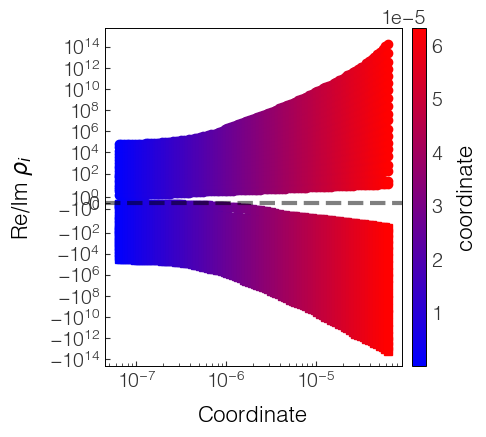

In [27]:
ProbeGapSpectroscopy.plot_eigenrhos_scatter(Nmodes=20,versus_coord=True)
plt.gcf().axes[0].set_xscale('log')

Text(0.5, 0, 'Gap size')

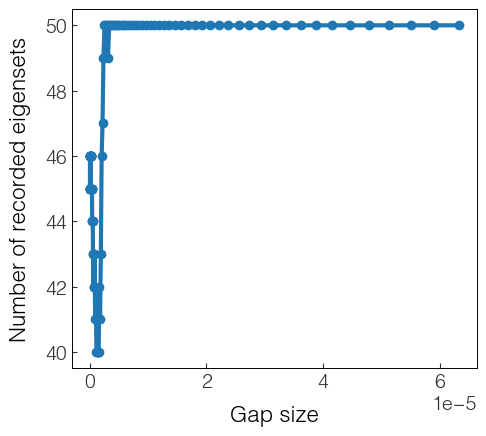

In [28]:
gaps = ProbeGapSpectroscopy._recorded_eigenrhos.keys()
Ns = [len(ProbeGapSpectroscopy._recorded_eigenrhos[gap]) for gap in gaps]
plt.plot(gaps,Ns,marker='o')
plt.ylabel('Number of recorded eigensets')
plt.xlabel('Gap size')

## Classify and plot dispersion of eigenmodes with gap

Now that gap spectroscopy has been computed, ideally there at at least $N_\mathrm{max}$ eigenmodes mutually identified at all gaps up to some maximum gap coordinate $d_\mathrm{max}$.  Right now, this is just a disordered collection of modes.  Now it is time to "classify" them by an eigenmode index $\nu$, so that later calculations can deal with distinct eigenmodes as functions of $d$.  A proper classification will sort eigenmodes (smaller values of $\rho(d)$) with higher confinement to lower values of index $\nu$, and will also maintain smooth evolution of the resulting eigenvalue functions $\rho_\nu(d)$.  Calling `ProbeGapSpectroscopy` with suitable arguments will attempt a classification.  A successful classification shows continuous evolution of the functions $\rho_\nu(d)$ returned as 2D array by `ProbeGapSpectroscopy.get_eigenrhos_AWA`; the continuity (or not) of these classified functions can be visualized with `ProbeGapSpectroscopy.plot_eigenrhos`.

In [29]:
Nmodes=50
# Start from the highest reliable coordinate to make sure we don't miss the lowest order modes
ProbeGapSpectroscopy(Nmodes=Nmodes,reversed=True,by_rho=True,debug=False,coordmax=None)
eigenrhos = ProbeGapSpectroscopy.get_eigenrhos_AWA(Nmodes=Nmodes)
eigencharges = ProbeGapSpectroscopy.get_eigencharges_AWA()

Classifying eigensets by eigenindex, with reversal...
Looking for Nmodes=40 (maximum uniformly available in coordinate range).
	Progress: 99.00%<EigenProbe.ProbeSpectroscopy.ProbeGapSpectroscopyParallel.align_eigencharge_signs>:
	Aligning signage of 40 eigenmode charges over 100 coordinates...


Text(0.5, 0, 'Gap/a')

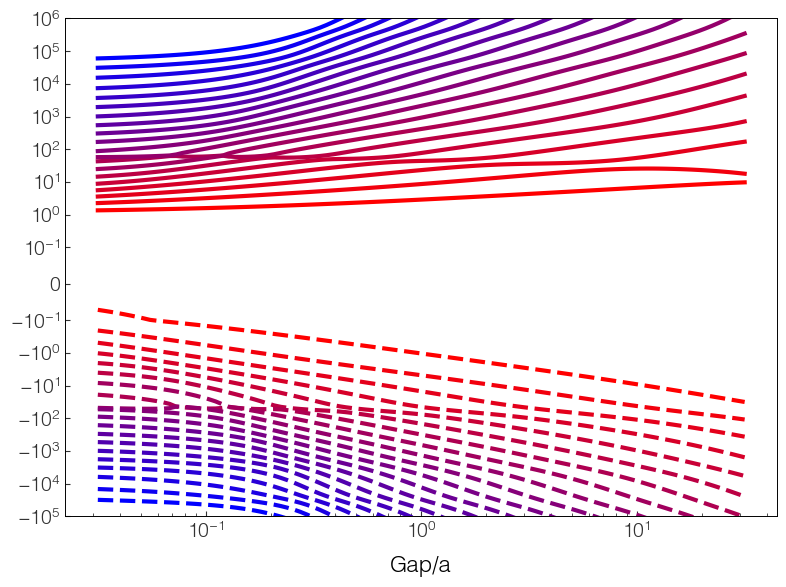

In [30]:
Nmodes_plot=20
colors=zip(np.linspace(1,0,Nmodes_plot),[0]*Nmodes_plot,np.linspace(0,1,Nmodes_plot))
plt.figure(figsize=(8,6))

a=P.get_a()
gaps=eigenrhos.axes[1]
for n in range(Nmodes_plot):
    c=next(colors)
    rhos=eigenrhos[n]
    plt.plot(gaps/a,rhos.real,marker='',color=c)
    plt.plot(gaps/a,rhos.imag,marker='',color=c,ls='--')
    
plt.gca().set_yscale('symlog',linthresh=.1)
plt.ylim(-1e5,1e6)
#plt.xlim(.0074,.0076)
#plt.xlim(np.min(freqs),.002)
plt.gca().set_xscale('log')
plt.xlabel('Gap/a')

## Compute brightness associated to eigenmodes

<EigenProbe.ProbeSpectroscopy.ProbeGapSpectroscopyParallel.get_eigenbrightness_AWA>:
	Computing brightnesses across 100 spectroscopy coordinates...


Text(0.5, 1.0, 'Brightness')

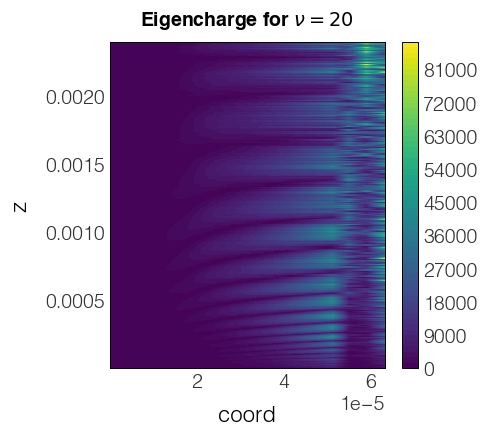

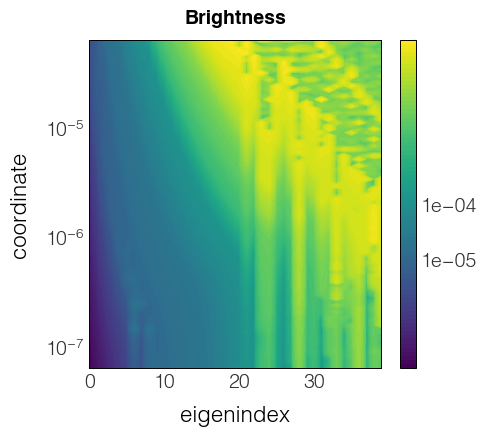

In [31]:
# If these functions appear smooth versus gap coordinate `d`, at least up to a maximum gap coordinate, then we have a successful classification.

eigenind=20
np.abs(ProbeGapSpectroscopy._eigencharges_AWA[eigenind].real).plot(plotter=plt.contourf)
plt.title(r'Eigencharge for $\nu=%i$'%eigenind)

angles=np.linspace(10,90,20)
all_vs = ProbeGapSpectroscopy.get_eigenbrightness_AWA(recompute=False,
                                                        angles=angles,
                                                        verbose=True)
plt.figure()
np.abs(all_vs).plot(plotter=plt.contourf,log_scale=True)
plt.gca().set_yscale('log')
plt.title('Brightness')

## Save after having computed properties of eigencharges

In [35]:
save=True
overwrite=False

if save:
    try: EP.save(ProbeGapSpectroscopy,overwrite=overwrite)
    except OSError: # didn't overwrite
        print('Tried to save ProbeGapSpectroscopy, but save file already exists.  Skipping.  You can choose `overwrite=True`.')

Successfully saved to file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=488)_ProbeGapSpectroscopy.pickle"!


# Build Encoded Eigenfields from gap spectroscopy

The `ProbeGapSpectroscopy` now describes how eigenmodes (up to $\nu<=\nu_\mathrm{max}$) evolve versus probe-sample distance $d$.  This information can be encoded into a version of a probe (an `EncodedEigenfields` object) that will contain the most compact description of $d$-dispersion of eigenmodes.  When provided with successfully classified eignmodes inside `ProbeGapSpectroscopy`, the `EncodedEigenfields` will identify a change-of-basis matrix $\Phi(d)$ such that $E(d)=\Phi(d) E(d_0)$.

Here $\Phi(d)$ denotes a matrix of column vectors that each describe a single eigenmode, such that element $\Phi{i,\nu}(d)$ denotes e.g. the value of eigencharge $Q_\nu(z_i$) at coordinate $z_i$ along the probe, or the value (Hankel transform) of electrostatic potential $A_{0,\nu}(q_i)$ at a momentum $q_i$.  The reference coordinate $d_0$ establishes a "basis" in which to describe eigenmodes at any other coordinate $d$ that is described by `ProbeGapSpectroscopy`.  A good choice is a gap size comparable to the largest momentum of interest for near-field interactions; larger gap values will render a basis incapable of describing high-momentum interactions that are more easily described with small-$d$ eigenmodes.  So, $d_0$ comparable to but smaller than the tip radius is suitable.

The matrix $\Phi(d)$ is computed with Sommerfeld integrals, which requires a dense and accurate quadrature grid of $\kappa$ values that will be a fixed attribute of `EncodedEigenfields` once instantiated.  This fixed grid will also be implicitly used to evaluate subsequent Sommerfeld integrals on reflection coefficients $r_p(q)$.

In [33]:
recompute=True
save=True
overwrite=False

try:
    if recompute: raise ValueError
    EE = EP.load(P, PS.EncodedEigenfields, overwrite_probe=True)
    
except (FileNotFoundError,ValueError):
    gap0 = P.get_a()/5
    Nmodes=15
    EE = PS.EncodedEigenfields(ProbeGapSpectroscopy,gap0=gap0, Nmodes=Nmodes,
                                kappa_min=None, kappa_max=20/a,
                                Nkappas=244*8, qquadrature=EP.numrec.GL)
    if save:
        try: EP.save(EE,overwrite=overwrite)
        except OSError: # didn't overwrite
            print('Tried to save EncodedEigenfields, but save file already exists.  Skipping.  You can choose `overwrite=True`.')

<EigenProbe.ProbeSpectroscopy.EncodedEigenfields.__init__>:
	Encoding 15 eigenfields to gap=4e-07 across 100 gap values from gap=(6.3e-08 to 6.3e-05)...
<EigenProbe.ProbeSpectroscopy.ProbeGapSpectroscopyParallel.get_probe_at_coord>:
	Updating eigenrhos to coordinate 3.88E-07...
	Updating eigencharges...
	Updating self impedance...
	Updating mirror impedance...
<EigenProbe.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
Successfully saved to file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=488)_EncodedEigenfields.pickle"!


## Build library for quick calculation of 2D material contrast

The `EncodedEigenfields` can be used to extremely quickly compute interaction with a 2D material atop a bulk substrate.  Such interactions can be parameterized uniquely in terms of $q_p$ and $\varepsilon$, the (unscreened) polariton momentum and substrate permittivity, respectively.  To accomplish this fast calculation, it suffices to compute a "library" of reflection matrices $R_0\equiv R(q_p,\varepsilon,d_0)$ between the eigenmodes at gap coordinate $d_0$.  (Thanks to internal structure of the Fresnel coefficient for this geometry, it actually suffices to compute the library (only) over a grid of screened polariton momentum values $\bar{q}_p=q_p/\kappa$ with $\kappa\equiv (1+\varepsilon)/2$.)  The reflection matrix at other values of $d$ is now simply $R(q_p,\varepsilon,d)=\Phi^T(d) R_0 \Phi(d)$.

To compute the library of $R_0$, specify a grid of $|\bar{q}_p|$ values.  The calculator will automatically expand these values to all four needed quadrants of the complex plane.  (Interestingly, unlike complex-valued temporal frequencies, there is no apparent "upper half complex plane" constraint for $\bar{q}_p$.)

In [34]:
recompute=True
save=True
overwrite=False

if not hasattr(EE,'Rmat2D_interp_subs_r') or recompute:
    q0 = 1/EE.get_probe().get_a() # A typical scale for qp
    qps = np.logspace(-3, 2, 100) * q0
    EE.build_Rmat2D_library(qps,
                            interp_kwargs = dict(s=0,kx=1,ky=1)) # smoothing factor `s=0` is for interpolation, `kx` and `ky` are degrees of spline

    if save:
        try: EP.save(EE,overwrite=overwrite)
        except OSError: # didn't overwrite
            print('Tried to save EncodedEigenfields, but save file already exists.  Skipping.  You can choose `overwrite=True`.')

<EigenProbe.ProbeSpectroscopy.EncodedEigenfields.build_Rmat2D_library>:
	Computing library of 2D material reflectance matrices from 15 eigenfields to 100 x 100 qp values...
	Total quadrature time: 31.00s, time per quadrature evaluation: 5.28E-05s
Basis has length 50
Finished gap=3.1e-05, elapsed time: 32 s
	Total quadrature time: 30.99s, time per quadrature evaluation: 5.28E-05s
Basis has length 50
Finished gap=3.9e-05, elapsed time: 32 s
	Total quadrature time: 30.63s, time per quadrature evaluation: 5.22E-05s
Basis has length 50
Finished gap=4.8e-05, elapsed time: 32 s
	Total quadrature time: 31.19s, time per quadrature evaluation: 5.32E-05s
Basis has length 50
Finished gap=4.5e-05, elapsed time: 32 s
	Total quadrature time: 21.45s, time per quadrature evaluation: 3.66E-05s
Basis has length 50
Finished gap=5.1e-05, elapsed time: 22 s
	Total quadrature time: 21.58s, time per quadrature evaluation: 3.68E-05s
Basis has length 50
Finished gap=5.5e-05, elapsed time: 23 s
	Total quadrature

# Probe Frequency Spectroscopy

The probe's near-field interaction is in principle entirely described by the set of eigenvalues and eigencharges, $\rho_\nu$ and $Q_\nu$, respectively, identified a single probe-sample gap $d=d_0$.  Their disperson with $d$ is identifiable "on-the-fly" by (electrostatic) field propagators (as done inside `Probe.EradVsGap`) or once-and-for-all by `ProbeGapSpectroscopy` and optionally `EncodedEigenfields`.  However, none of these know about the frequency ($\omega$)-dependent probe response; if any such dependence exists, it comes from "antenna" (electrodynamic) characteristics of the probe's self-impedance matrix, from which eigenmodes are usually obtained only at an exemplary $\omega$.

On the other hand, the full set of $\rho_\nu(\omega)$ and $Q_\nu(\omega)$ at the reference probe-sample gap $d_0$ can be computed through iterative calculation of the self-impedance matrix at a span of $\omega$ values and by solving the generalized eigenvalue problem at each such $\omega$.  `ProbeFrequencySpectroscopyParallel` will do this, parallelized over $\omega$ using `joblib`.

## Load or build spectroscopy

In [16]:
freqs=np.linspace(0.5,80,200)*freq_THz

recompute=True
save=True
overwrite=False

try:
    if recompute: raise ValueError
    ProbeFreqSpectroscopy = EP.load(P, PS.ProbeFrequencySpectroscopyParallel, overwrite_probe=True)
    
except (FileNotFoundError,ValueError):
    ProbeFreqSpectroscopy = PS.ProbeFrequencySpectroscopyParallel(Probe=P, freqs=freqs,
                                                                 ncpus=8, backend='loky',
                                                                 Nmodes=20, reversed=False)
    if save:
        try: EP.save(ProbeFreqSpectroscopy,overwrite=overwrite)
        except OSError: # didn't overwrite
            print('Tried to save ProbeFreqSpectroscopy, but save file already exists.  Skipping.  You can choose `overwrite=True`.')

	Parallel calculation retrieved 8 results!
	Parallel calculation retrieved 8 results!
	Parallel calculation retrieved 8 results!
	Parallel calculation retrieved 8 results!
	Parallel calculation retrieved 8 results!
	Parallel calculation retrieved 8 results!
	Total quadrature time: 20.04s, time per quadrature evaluation: 3.42E-05s
Basis has length 50
Finished gap=5.5e-05, elapsed time: 21 s
Could not add probe to `ProbesCollection.` 
A probe named "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=488" is already instantiated!  If you wish to overwrite this probe, remove it from the collection of probes by using the `del` command!
You may avert this error by passing keyword `overwrite=True` to `load`!
Starting freq=43
<__init__.Probe.reset_eigenproperties>:
	Resetting eigenproperties...
Finished freq=43, elapsed time: 66 s
Could not add probe to `ProbesCollection.` 
A probe named "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=488" is already instantiated!  If you wish to overwrite this pr

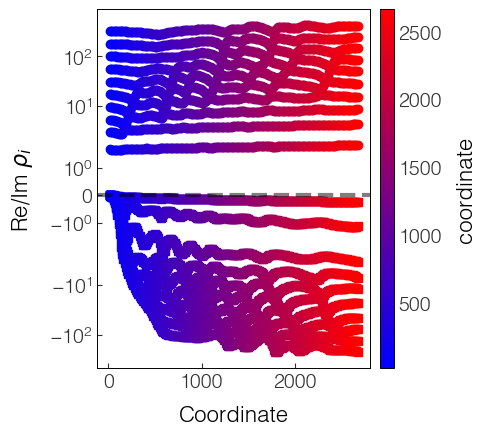

In [17]:
ProbeFreqSpectroscopy.plot_eigenrhos_scatter(Nmodes=10,versus_coord=True)
plt.gcf().axes[0].set_xscale('linear')

## Classify and plot dispersion of probe poles

Now that frequency spectroscopy has been computed, ideally there at at least $N_\mathrm{max}$ eigenmodes mutually identified at all frequencies.  Right now, this is just a disordered collection of modes.  Now it is time to "classify" them by an eigenmode index $\nu$, so that later calculations can deal with distinct eigenmodes as functions of $\omega$.  A proper classification will sort eigenmodes (smaller values of $\rho(\omega)$) with higher confinement to lower values of index $\nu$, and will also maintain smooth evolution of the resulting eigenvalue functions $\rho_\nu(\omega)$.  Calling `ProbeFreqSpectroscopy` with suitable arguments will attempt a classification.  A successful classification shows continuous evolution of the functions $\rho_\nu(\omega)$ returned as 2D array by `ProbeFreqSpectroscopy.get_eigenrhos_AWA`; the continuity (or not) of these classified functions can be visualized with `ProbeFreqSpectroscopy.plot_eigenrhos`.

It is natural that the eigenmodes and $\rho(\omega)$ (and their "brightness") will show "resonances" at frequencies of antenna modes of the probe, where the eigenmodes will show selectively higher dipole / quadrupole / etc. moments along the probe's length in comparison to the free-space wavelength.  In this respect, the probe-sample near-field interaction is somewhat modulated through this coupling between eigenmodes and far-field radiance.

After `ProbeFreqSpectroscopy` has computed this dependence and classified the eigenmodes, how are they used?  `ProbeFreqSpectroscopy.set_eigenset(Probe,freq)` will load eigenmodes computed at $\omega$ (`freq`) into `Probe`.  (These can in principle also be loaded into the corresponding `EncodedEigenfields` instance to "update" the eignemodes at reference probe-sample gap $d_0$, although this feature hasn't been implemented yet.)

In [18]:
ProbeFreqSpectroscopy(Nmodes=20,reverse=False,by_rho=True,debug=False)
eigenrhos = ProbeFreqSpectroscopy.get_eigenrhos_AWA(Nmodes=20)
eigencharges = ProbeFreqSpectroscopy.get_eigencharges_AWA()

Classifying eigensets by eigenindex...
	Progress: 99.50%<ProbeSpectroscopy.ProbeFrequencySpectroscopyParallel.align_eigencharge_signs>:
	Aligning signage of 20 eigenmode charges over 200 coordinates...


Text(0.5, 0, 'Frequency  (cm$^{-1}$)')

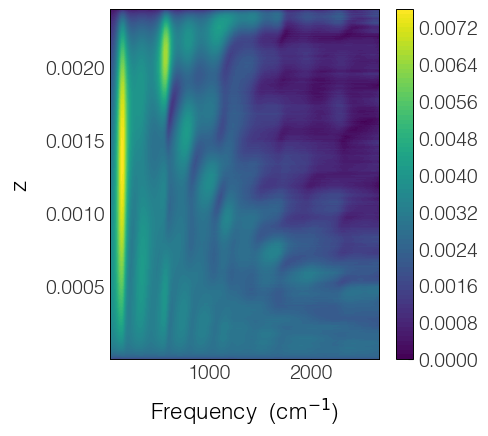

In [19]:
np.abs(eigencharges[0]).plot(plotter=plt.contourf) # Ideally, the profile of eigencharges evolves smoothly with `
plt.xlabel(r'Frequency  (cm$^{-1}$)')

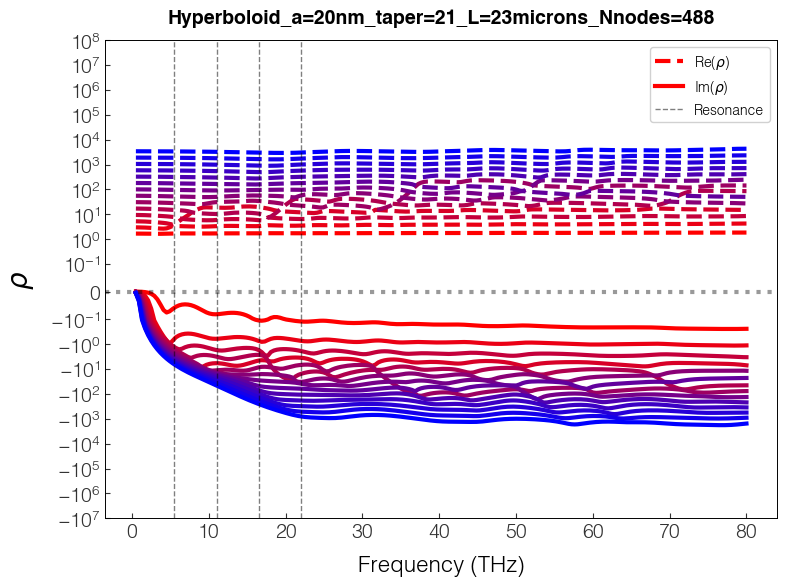

In [20]:
N=14
colors=zip(np.linspace(1,0,N),[0]*N,np.linspace(0,1,N))
plt.figure(figsize=(8,6))

freqs=eigenrhos.axes[1]
for n in range(N):
    c=next(colors)

    if n==0:
        label1=r'Re($\rho$)'
        label2=r'Im($\rho$)'
    else: label1=label2=None
        
    rhos=eigenrhos[n]
    plt.plot(freqs/freq_THz,rhos.real,marker='',color=c,label=label1,ls='--')
    plt.plot(freqs/freq_THz,rhos.imag,marker='',color=c,label=label2)
    
plt.gca().set_yscale('symlog',linthresh=.1)
plt.ylim(-1e7,1e8)
#plt.xlim(.0074,.0076)
#plt.xlim(np.min(freqs),.002)
plt.xlabel('Frequency (THz)')
plt.ylabel(r'$\rho$',fontsize=20)
plt.legend(frameon=True)

#--- Plot some antenna mode frequencies

f=.88 # Geometry of the probe influences at what energies the antenna resonances appear.  This proportionality factor is very much non-universal.
kwargs=dict(color='k',ls='--',alpha=.5,lw=1)
plt.axvline(f/(2*L)/freq_THz,**kwargs) #This is where probe ~ lambda/2 antenna - radiative Q?
plt.axvline(f/L/freq_THz,**kwargs) #This is where probe ~ lambda antenna - radiative Q?
plt.axvline(f*3/(2*L)/freq_THz,**kwargs)
plt.axvline(f*2/(L)/freq_THz,label='Resonance',**kwargs)

plt.axhline(0,ls=':',color='k',alpha=.4)
plt.title(ProbeFreqSpectroscopy.get_probe().get_name())
plt.legend()